# Feature Selection

## 1. [FILTER METHODS](#scrollTo=BLVzn55ihVaf)
Filter methods use statistical techniques to assess the relationship between input features and the target variable, selecting those with the strongest associations.
- **Examples**: Correlation Matrix, Chi-square test, Weight of Evidence (WoE), ANOVA, Mutual information

## 2. [WRAPPING METHODS](#scrollTo=2W0-KlE09dTC&line=1&uniqifier=1)
Wrapping methods evaluate multiple feature subsets by training and testing a machine learning model, selecting features based on model performance.
- **Examples**: Forward Selection, Backward Elimination, Recursive Feature Elimination (RFE), Exhaustive Feature Searchn

## 3. [EMBEDDED METHODS](#scrollTo=NbyyGujD9kK4&line=1&uniqifier=1)
Embedded methods perform feature selection during the process of model training, using the inherent properties of specific algorithms.
- **Examples**: LASSO (L1 regularization), Ridge (L2 regularization), Decision Trees (feature importance)

# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Dataset Loading

This data was extracted from the 1994 Census bureau database by Ronny Kohavi and Barry Becker (Data Mining and Visualization, Silicon Graphics). A set of reasonably clean records was extracted using the following conditions: ((AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0)). The prediction task is to determine whether a person makes over $50K a year.

In [2]:
from sklearn.datasets import fetch_openml

# Load the "Adult (Census Income)" dataset
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

# Handle categorical encoding for categorical features
df['sex'] = df['sex'].map({'Male': 0, 'Female': 1})

target_name = "class"
df[target_name] = df[target_name].map({'<=50K': 0, '>50K': 1}).astype('int')
target = df[target_name]

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,0,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,0,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,0,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,0,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,1,0,0,30,United-States,0


In [4]:
print(df.shape)

(48842, 15)


1. **age**: (continuous, positive integer) The age of the individual.
2. **workclass**: (categorical, 9 distinct values) Simplified employment status of an individual
3. **fnlwgt**: (continuous, positive integer) Final weight of the record. Basically interpret as the number of
people represented by this row.
4. **education-num**: (categorical, 13 distinct values) The education level, in ascending positive integer
value.
5. **education**: (categorical, 13 distinct values) The education level. Note that for simplicity, we will
ignore this column because of the existence of education-num column.
6. **marital-status**: (categorical, 7 distinct values) Marital status of a person.
7. **occupatioin**: (categorical, 15 distinct values) Rough category of the occupation.
8. **relationship**: (categorical, 6 distinct values) Relationship in terms of the family. Note that we ignore
this column since the semantic is somewhat covered by marital-status and gender.
9. **race**: (categorical, 5 distinct values) Race of the person.
10. **sex**: (boolean) gender at-birth.
11. **capital-gain**: (continuous) Dollar gain of capital.
12. **capital-loss**: (continuous) Dollar loss of capital.
13. **hours-per-week**: (continous positive integer) Working hours per week.
14. **native-country**: (categorical, 41 distinct values) Country at birth.
15. **class**: ≥ 50K or < 50K (per year).


In [5]:
df.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [6]:
df.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
count,48842.000000,46043,4.884200e+04,48842,48842.000000,48842,46033,48842,48842,48842.0,48842.000000,48842.000000,48842.000000,47985,48842.000000
unique,NaN,8,NaN,16,NaN,7,14,6,5,2.0,NaN,NaN,NaN,41,NaN
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,0.0,NaN,NaN,NaN,United-States,NaN
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650.0,NaN,NaN,NaN,43832,NaN
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,0.239282
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,0.426649
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,0.000000
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,0.000000
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,0.000000
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,0.000000


In [7]:
# Define Categorical and Numerical columns
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Step 2: Handle missing values in categorical columns by filling with 'no data'
for col in categorical_cols:
    df[col] = df[col].astype('category')
    df[col] = df[col].cat.add_categories(['no data'])
df[categorical_cols] = df[categorical_cols].fillna('no data')


In [8]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


# Create Highly Correlated Features for Illustration

In [9]:
# Create a highly correlated feature based on 'education-num'
df['education-num-high-corr'] = df['education-num'] * 1.05 + np.random.normal(0, 0.5, size=len(df))

# Create another highly correlated feature based on 'age'
df['age-high-corr'] = df['age'] * 1.1 + np.random.normal(0, 1, size=len(df))

# Create a highly correlated feature with the target
df['high-corr-target'] = df['class'] * 10 + np.random.normal(0, 1, size=len(df))

# Create highly dependent categorical features
df['workclass_high_dep'] = df['workclass'].apply(lambda x: 'Private' if x == 'Private' else 'Other')

# Create a non-linear relationship between 'education-num' and a new feature
df['education-num-nonlinear'] = np.sin(df['education-num'] * 0.5) + df['education-num'] * 0.3 + np.random.normal(0, 0.2, size=len(df))

In [10]:
numerical_cols

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [11]:
numerical_cols.extend(['education-num-high-corr', 'age-high-corr', 'high-corr-target', 'education-num-nonlinear'])
categorical_cols.extend(['workclass_high_dep'])

# FILTER METHODS

## Correlation coefficients, Correlation Matrix

A correlation matrix shows the relationship (linear dependence) between numerical features. Features with high correlation (near 1 or -1) are considered strongly related, and one may be excluded to reduce multicollinearity.

We'll use [Pearson correlation](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) by default (which assumes a linear relationship between features). The correlation coefficient varies between -1 and 1:
*   1 means a perfect positive correlation.
*   -1 means a perfect negative correlation
*   0 means no linear correlation.


### Numerical Pearson correlation

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,education-num-high-corr,age-high-corr,high-corr-target,education-num-nonlinear
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,-0.076628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,0.030940,-0.038761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,0.077229,-0.003706,0.125146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-loss,0.056944,-0.004366,0.080972,-0.031441,NaN,NaN,NaN,NaN,NaN,NaN
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,NaN,NaN,NaN,NaN,NaN
education-num-high-corr,0.030177,-0.039173,0.983135,0.122598,0.079088,0.142173,NaN,NaN,NaN,NaN
age-high-corr,0.997783,-0.076130,0.031164,0.077033,0.056533,0.071259,0.030363,NaN,NaN,NaN
high-corr-target,0.224080,-0.005543,0.323479,0.217183,0.142973,0.222123,0.319113,0.223563,NaN,NaN
education-num-nonlinear,0.105079,-0.020683,0.819434,0.145193,0.087918,0.138493,0.804555,0.104942,0.333337,NaN


Time taken: 0.08 seconds


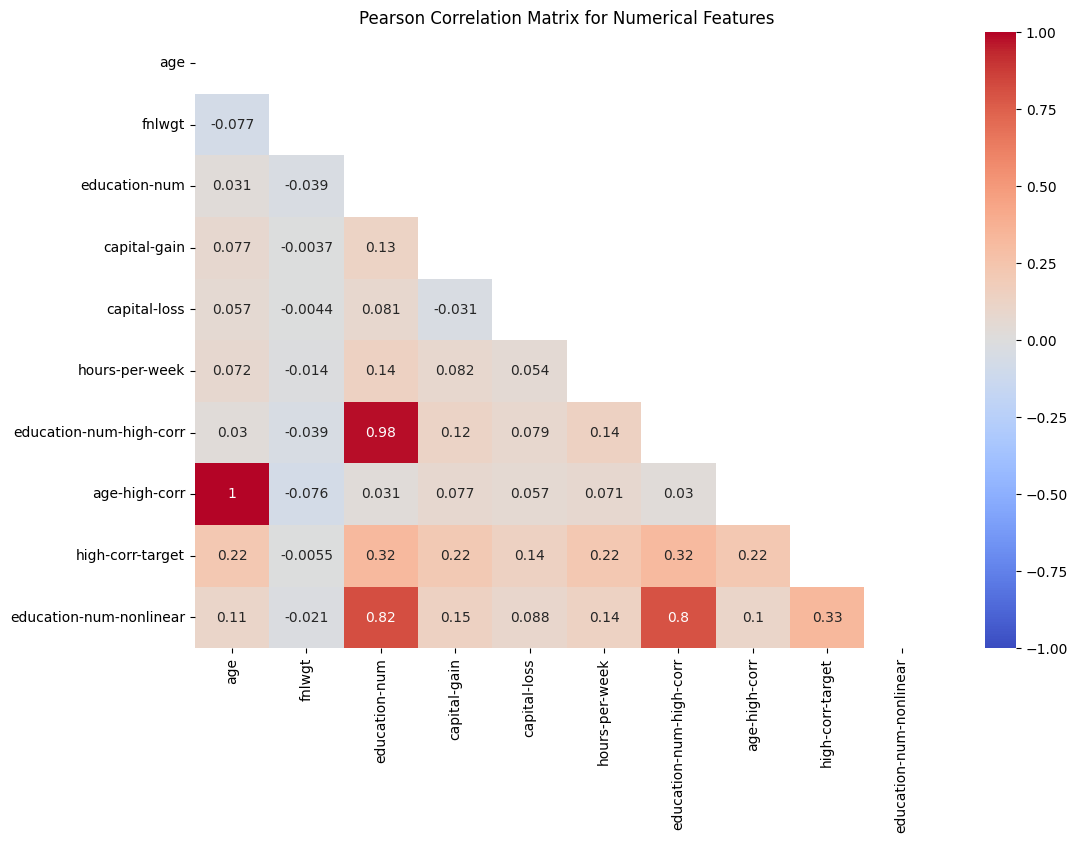

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import time

start_t = time.time()
# Calculate correlation matrix for numerical features
corr_matrix = df[numerical_cols].corr(method='pearson')
corr_matrix = corr_matrix.mask(np.triu(np.ones_like(corr_matrix, dtype=bool)))
end_t = time.time()
display(corr_matrix)

print(f"Time taken: {end_t - start_t:.2f} seconds")
# Plot correlation matrix heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1) # Pay attention to min and max!
plt.title('Pearson Correlation Matrix for Numerical Features')
plt.show()


### Numerical [Spearman Correlation](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient)
Measures monotonic relationships (captures both linear and non-linear monotonic relationships).

Time taken: 0.14 seconds


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,education-num-high-corr,age-high-corr,high-corr-target,education-num-nonlinear
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,-0.077504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,0.063212,-0.029643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,0.124436,-0.008755,0.118871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-loss,0.057584,-0.000944,0.077017,-0.066328,NaN,NaN,NaN,NaN,NaN,NaN
hours-per-week,0.146604,-0.016334,0.164437,0.091914,0.060063,NaN,NaN,NaN,NaN,NaN
education-num-high-corr,0.064007,-0.030214,0.955289,0.116182,0.074589,0.162836,NaN,NaN,NaN,NaN
age-high-corr,0.997549,-0.076957,0.062559,0.123996,0.056980,0.145531,0.063338,NaN,NaN,NaN
high-corr-target,0.198147,-0.003843,0.242385,0.204006,0.102974,0.198096,0.235216,0.197473,NaN,NaN
education-num-nonlinear,0.087318,-0.021736,0.801665,0.108349,0.065644,0.132926,0.764027,0.086638,0.206545,NaN


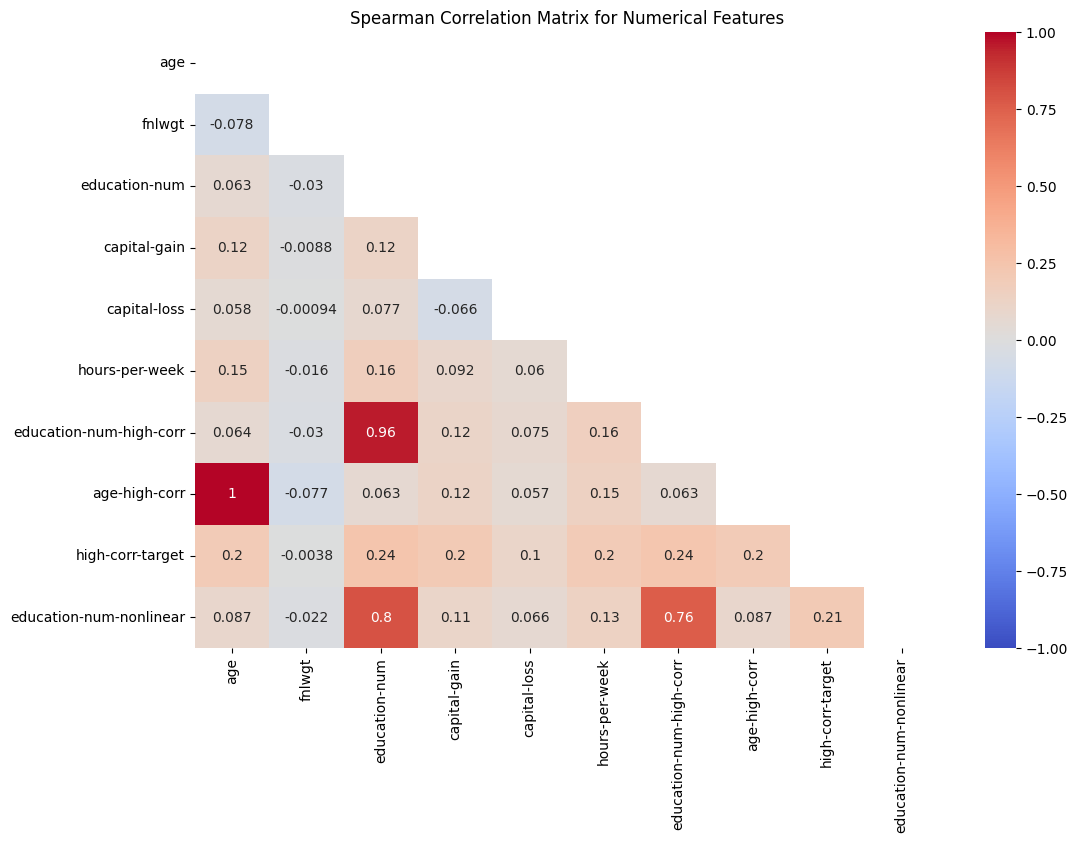

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import time

start_t = time.time()
# Calculate correlation matrix for numerical features
corr_matrix = df[numerical_cols].corr(method='spearman')
corr_matrix = corr_matrix.mask(np.triu(np.ones_like(corr_matrix, dtype=bool)))
end_t = time.time()
print(f"Time taken: {end_t - start_t:.2f} seconds")
display(corr_matrix)

# Plot correlation matrix heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1) # Pay attention to min and max!
plt.title('Spearman Correlation Matrix for Numerical Features')
plt.show()

### Numerical [Kendall Correlation](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient)
Measures ordinal association between two variables, capturing monotonic relationships.

Time taken: 1.07 seconds


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,education-num-high-corr,age-high-corr,high-corr-target,education-num-nonlinear
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,-0.052383,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,0.050856,-0.021378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-gain,0.100677,-0.007001,0.103358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital-loss,0.047058,-0.000771,0.067488,-0.064311,NaN,NaN,NaN,NaN,NaN,NaN
hours-per-week,0.111001,-0.011818,0.129756,0.079971,0.052643,NaN,NaN,NaN,NaN,NaN
education-num-high-corr,0.047227,-0.020137,0.867504,0.093255,0.060313,0.118632,NaN,NaN,NaN,NaN
age-high-corr,0.964486,-0.051452,0.049626,0.099276,0.046076,0.108904,0.046099,NaN,NaN,NaN
high-corr-target,0.133583,-0.002522,0.175150,0.163197,0.083203,0.143076,0.156952,0.131730,NaN,NaN
education-num-nonlinear,0.061062,-0.014420,0.670495,0.087013,0.053068,0.096364,0.581521,0.059892,0.137467,NaN


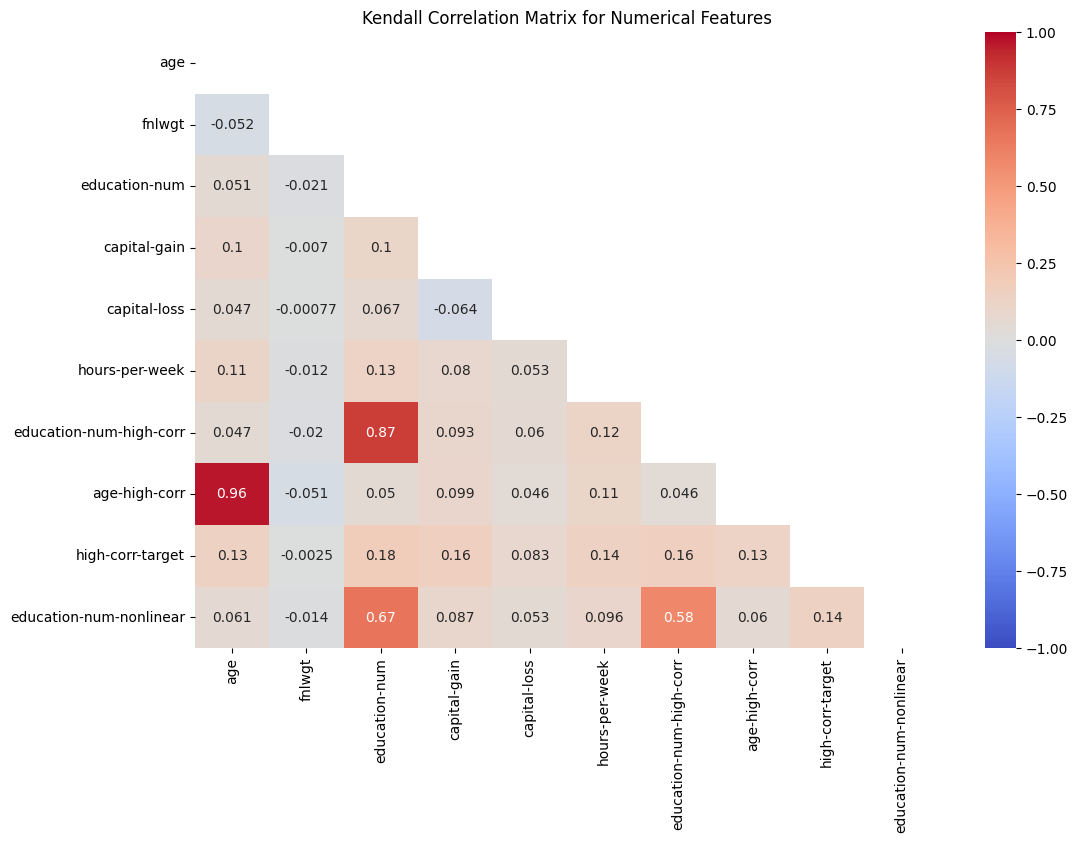

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import time

start_t = time.time()
# Calculate correlation matrix for numerical features
corr_matrix = df[numerical_cols].corr(method='kendall')
corr_matrix = corr_matrix.mask(np.triu(np.ones_like(corr_matrix, dtype=bool)))
end_t = time.time()
print(f"Time taken: {end_t - start_t:.2f} seconds")
display(corr_matrix)

# Plot correlation matrix heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1) # Pay attention to min and max!
plt.title('Kendall Correlation Matrix for Numerical Features')
plt.show()

### Numerical - Binary Point-biserial correlation

To calculate the correlation between numerical features and a binary target (like <=50K or >50K in the Adult dataset), let us use [Point-Biserial Correlation] (https://en.wikipedia.org/wiki/Point-biserial_correlation_coefficient)

In [15]:
from scipy.stats import pointbiserialr

threshold = 0.7
# Calculate Point-Biserial Correlation between each numerical feature and the binary target
start_t = time.time()
for col in numerical_cols:
    prefix = ''
    corr, p_value = pointbiserialr(df[col], df['class'])
    if abs(corr) > threshold:
        prefix = '!!! ATTENTION !!!'
    print(f"{prefix} Correlation between {col} and target: {corr:.4f} (p-value: {p_value:.4f})")

 Correlation between age and target: 0.2304 (p-value: 0.0000)
 Correlation between fnlwgt and target: -0.0063 (p-value: 0.1612)
 Correlation between education-num and target: 0.3326 (p-value: 0.0000)
 Correlation between capital-gain and target: 0.2230 (p-value: 0.0000)
 Correlation between capital-loss and target: 0.1476 (p-value: 0.0000)
 Correlation between hours-per-week and target: 0.2277 (p-value: 0.0000)
 Correlation between education-num-high-corr and target: 0.3281 (p-value: 0.0000)
 Correlation between age-high-corr and target: 0.2298 (p-value: 0.0000)
!!! ATTENTION !!! Correlation between high-corr-target and target: 0.9735 (p-value: 0.0000)
 Correlation between education-num-nonlinear and target: 0.3433 (p-value: 0.0000)


For each numerical feature, this code outputs the Point-Biserial Correlation coefficient (between -1 and 1) and the p-value. The closer the correlation is to -1 or 1, the stronger the relationship between the feature and the binary target.

How to Interpret:
*  **A positive correlation** means that as the numerical feature increases, the likelihood of the positive class (>50K) increases.
*  **A negative correlation** means that as the numerical feature increases, the likelihood of the positive class decreases.
*  **p-value:** If the p-value is small (typically < 0.05), the correlation is statistically significant.

### Categorical - Categorican Cramér's V
Use [Cramér's V](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V) to assess correlations between **categorical features**.

In [16]:
from scipy.stats import chi2_contingency

# Function to calculate Cramér's V
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Example: Calculate Cramér's V
for i, col1 in enumerate(categorical_cols):
    for col2 in categorical_cols[i+1:]:
        cramers_v_val = cramers_v(df[col1], df[col2])
        print(f"Cramér's V between {col1} and {col2}: {cramers_v_val:.4f}")

Cramér's V between workclass and education: 0.1000
Cramér's V between workclass and marital-status: 0.0855
Cramér's V between workclass and occupation: 0.4001
Cramér's V between workclass and relationship: 0.1008
Cramér's V between workclass and race: 0.0583
Cramér's V between workclass and sex: 0.1518
Cramér's V between workclass and native-country: 0.0428
Cramér's V between workclass and workclass_high_dep: 1.0000
Cramér's V between education and marital-status: 0.0909
Cramér's V between education and occupation: 0.1867
Cramér's V between education and relationship: 0.1227
Cramér's V between education and race: 0.0730
Cramér's V between education and sex: 0.0932
Cramér's V between education and native-country: 0.1303
Cramér's V between education and workclass_high_dep: 0.1572
Cramér's V between marital-status and occupation: 0.1317
Cramér's V between marital-status and relationship: 0.4882
Cramér's V between marital-status and race: 0.0830
Cramér's V between marital-status and sex: 0

## [Mutual Information](https://en.wikipedia.org/wiki/Mutual_information)

Mutual Information quantifies the amount of information gained about the target from knowing the feature values. It works well for both numerical and categorical features and is useful for non-linear relationships.

Higher MI values mean the feature provides more information about the target, which suggests it could be more important for predictive tasks. However, **MI is not bounded between -1 and 1** like correlation and works well for detecting non-linear relationships.

In [17]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information between numerical features and the target
mutual_info = mutual_info_classif(df[numerical_cols], df['class'])

# Print mutual information scores
for i, col in enumerate(numerical_cols):
    print(f"Mutual Information between {col} and target: {mutual_info[i]:.4f}")

Mutual Information between age and target: 0.0697
Mutual Information between fnlwgt and target: 0.0394
Mutual Information between education-num and target: 0.0655
Mutual Information between capital-gain and target: 0.0856
Mutual Information between capital-loss and target: 0.0348
Mutual Information between hours-per-week and target: 0.0399
Mutual Information between education-num-high-corr and target: 0.0646
Mutual Information between age-high-corr and target: 0.0678
Mutual Information between high-corr-target and target: 0.5503
Mutual Information between education-num-nonlinear and target: 0.0541


## [Weight of Evidence, WoE](https://www.listendata.com/2015/03/weight-of-evidence-woe-and-information.html)

**Interpretation of WoE:**
* Positive WoE indicates that a category is associated with a higher likelihood of the target event (in this case, income > 50K).
* Negative WoE suggests that a category is associated with a lower likelihood of the target event.
* A WoE value of 0 means that the category does not provide any predictive power.

**Interpretation of IV:**
* IV < 0.02: Not Predictive
* 0.02 - 0.1: Weak Predictor
* 0.1 - 0.3: Medium Predictor
* 0.3 - 0.5: Strong Predictor
* IV > 0.5: Very Strong Predictor (possible overfitting or data leakage)

In [18]:
# Function to calculate WoE and Information Value (IV) using numpy
def calc_woe_iv(df, feature, target):
    # Calculate the cross-tabulation of the feature against the target
    crosstab = pd.crosstab(df[feature], df[target], dropna=False).astype(float)

    # Add total counts
    crosstab['total'] = crosstab[0] + crosstab[1]

    # Calculate event and non-event rates
    crosstab['event_rate'] = crosstab[1] / crosstab[1].sum()
    crosstab['non_event_rate'] = crosstab[0] / crosstab[0].sum()

    # Handle division by zero and calculate WoE
    crosstab['woe'] = np.log((crosstab['event_rate'] + 1e-10) / (crosstab['non_event_rate'] + 1e-10))

    # Calculate Information Value (IV)
    crosstab['iv'] = (crosstab['event_rate'] - crosstab['non_event_rate']) * crosstab['woe']
    iv = crosstab['iv'].sum()

    return crosstab[['event_rate', 'non_event_rate', 'woe', 'iv']], iv

# Example: Calculate WoE and Information Value (IV) for 'education'
woe_education, iv_education = calc_woe_iv(df, 'education', 'class')
print("WoE for education:", woe_education)
print("Information Value (IV) for education: {:.4f}".format(iv_education))


WoE for education: class         event_rate  non_event_rate       woe        iv
education                                                   
10th            0.007444        0.035042 -1.549127  0.042753
11th            0.007872        0.046293 -1.771670  0.068069
12th            0.004107        0.016391 -1.383996  0.017001
1st-4th         0.000685        0.006433 -2.240401  0.012878
5th-6th         0.002310        0.012973 -1.725486  0.018398
7th-8th         0.005305        0.024034 -1.510831  0.028297
9th             0.003508        0.019244 -1.702089  0.026783
Assoc-acdm      0.035338        0.031974  0.100042  0.000337
Assoc-voc       0.044665        0.041421  0.075401  0.000245
Bachelors       0.283477        0.126820  0.804363  0.126009
Doctorate       0.036879        0.004387  2.128979  0.069174
HS-grad         0.214170        0.357449 -0.512223  0.073391
Masters         0.124840        0.032243  1.353719  0.125349
Preschool       0.000086        0.002207 -3.250097  0.006895
Prof-

## [ANOVA - Analysis of Variance](https://en.wikipedia.org/wiki/Analysis_of_variance)

The ANOVA F-statistic tests whether the means of a numerical feature significantly differ between two groups (in this case, income levels <=50K vs >50K). Here’s how to interpret the results:

* **F-statistic:**

A high F-statistic indicates that there is a significant difference in the mean values of the feature across the groups, implying that the feature may have predictive power in determining the target variable.
A low F-statistic suggests no significant difference in means, implying the feature might not be useful for prediction.
* **p-value:**

If the p-value is less than 0.05, it means the feature has a significant effect on the target, i.e., the means of the groups are significantly different.
A high p-value (e.g., > 0.05) means there is no significant difference between the means for the groups, implying the feature might not be relevant for predicting the target.

In [19]:
from sklearn.feature_selection import f_classif

# Calculate ANOVA F-statistic for numerical features
f_stat, p_values = f_classif(df[numerical_cols], df['class'])
for i, col in enumerate(numerical_cols):
    print(f"ANOVA F-statistic for {col}: {f_stat[i]:.4f}, p-value: {p_values[i]:.4f}")

# Create a structured numpy array with feature names and F-statistic scores
dtype = [('feature', 'U50'), ('score', 'f8')]  # Define data types for the structured array
features_scores = np.array(list(zip(numerical_cols, f_stat)), dtype=dtype)

# Sort features by F-statistic scores in descending order
features_scores = np.sort(features_scores, order='score')[::-1]

# Print the sorted features with their scores in a table format
print("\nSorted features by ANOVA F-statistic:")
print(f"{'Feature Name':<30}{'F-Statistic Score':>20}")

# Print each feature with fixed-length formatting
for row in features_scores:
    print(f"{row['feature']:<30}{row['score']:>20.4f}")


ANOVA F-statistic for age: 2737.2071, p-value: 0.0000
ANOVA F-statistic for fnlwgt: 1.9625, p-value: 0.1612
ANOVA F-statistic for education-num: 6075.3694, p-value: 0.0000
ANOVA F-statistic for capital-gain: 2556.1791, p-value: 0.0000
ANOVA F-statistic for capital-loss: 1087.0276, p-value: 0.0000
ANOVA F-statistic for hours-per-week: 2670.3621, p-value: 0.0000
ANOVA F-statistic for education-num-high-corr: 5890.5361, p-value: 0.0000
ANOVA F-statistic for age-high-corr: 2723.7759, p-value: 0.0000
ANOVA F-statistic for high-corr-target: 886075.2194, p-value: 0.0000
ANOVA F-statistic for education-num-nonlinear: 6525.7714, p-value: 0.0000

Sorted features by ANOVA F-statistic:
Feature Name                     F-Statistic Score
high-corr-target                       886075.2194
education-num-nonlinear                  6525.7714
education-num                            6075.3694
education-num-high-corr                  5890.5361
age                                      2737.2071
age-high-co

## [Chi-Square Test](https://en.wikipedia.org/wiki/Chi-squared_test)

The Chi-Square test measures the statistical significance of the association between each categorical feature and the target variable.

**The higher the Chi-Square score, the stronger the association between the feature and the target.**

However, there's no absolute threshold for the Chi-Square score itself because the meaningfulness of the score depends on the number of observations and categories in the feature.

In [20]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
import numpy as np

# Encode categorical features
df_encoded = df[categorical_cols].apply(LabelEncoder().fit_transform)

# Chi-square test for association with the target
chi_scores, p_values = chi2(df_encoded, df['class'])
for i, col in enumerate(categorical_cols):
    print(f"Chi-square score for {col}: {chi_scores[i]:.4f}, p-value: {p_values[i]:.4f}")

# Create a structured numpy array with feature names and Chi-square scores
dtype = [('feature', 'U50'), ('score', 'f8')]  # Define data types for the structured array
features_scores = np.array(list(zip(categorical_cols, chi_scores)), dtype=dtype)

# Sort features by Chi-square scores in descending order
features_scores = np.sort(features_scores, order='score')[::-1]

# Print the sorted features with their scores in a table format
print("\nSorted features by Chi-square score:")
print(f"{'Feature Name':<30}{'Chi-square Score':>20}")

# Print each feature with fixed-length formatting
for row in features_scores:
    print(f"{row['feature']:<30}{row['score']:>20.4f}")


Chi-square score for workclass: 137.6363, p-value: 0.0000
Chi-square score for education: 457.1174, p-value: 0.0000
Chi-square score for marital-status: 1680.1236, p-value: 0.0000
Chi-square score for occupation: 7.5223, p-value: 0.0061
Chi-square score for relationship: 5569.4609, p-value: 0.0000
Chi-square score for race: 47.9499, p-value: 0.0000
Chi-square score for sex: 1504.0286, p-value: 0.0000
Chi-square score for native-country: 20.9292, p-value: 0.0000
Chi-square score for workclass_high_dep: 85.4217, p-value: 0.0000

Sorted features by Chi-square score:
Feature Name                      Chi-square Score
relationship                             5569.4609
marital-status                           1680.1236
sex                                      1504.0286
education                                 457.1174
workclass                                 137.6363
workclass_high_dep                         85.4217
race                                       47.9499
native-country        

The same happeins if we use SelectKBest with score_func=chi2

In [21]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
df_encoded = df[categorical_cols].apply(LabelEncoder().fit_transform)

# Apply SelectKBest to select top k features
k = 5  # You can adjust k to select the desired number of top features
selector = SelectKBest(score_func=chi2, k=k)
selector.fit(df_encoded, df['class'])

# Get the selected features
selected_features = [col for col, is_selected in zip(categorical_cols, selector.get_support()) if is_selected]
print("Top", k, "selected categorical features based on Chi-Square scores:", selected_features)

Top 5 selected categorical features based on Chi-Square scores: ['workclass', 'education', 'marital-status', 'relationship', 'sex']


# WRAPPING METHODS

## [Forward Selection](https://scikit-learn.org/dev/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html)

In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
import time

# Prepare feature and target sets
X = df.drop('class', axis=1)
y = df['class']

# Encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Define the model
model = DecisionTreeClassifier()

# Forward selection
# Start the timer
start_time = time.time()
sfs = SequentialFeatureSelector(estimator=model, n_features_to_select='auto', direction='forward', cv=3)
sfs = sfs.fit(X, y) # You should use train split to find best features, not the whole dataset!

end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds")

# Selected features
selected_features_forward = list(X.columns[sfs.get_support()])
print("Selected features by Forward Selection:", selected_features_forward)

Time taken: 19.87 seconds
Selected features by Forward Selection: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'high-corr-target']


## [Backward Elimination](https://scikit-learn.org/dev/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html)

In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
import time

# Prepare feature and target sets
X = df.drop('class', axis=1)
y = df['class']

# Encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Define the model
model = DecisionTreeClassifier()

# Forward selection
# Start the timer
start_time = time.time()
sfs = SequentialFeatureSelector(estimator=model, n_features_to_select='auto', direction='backward', cv=3)
sfs = sfs.fit(X, y) # You should use train split to find best features, not the whole dataset!

end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds")

# Selected features
selected_features_backward = list(X.columns[sfs.get_support()])
print("Selected features by Backward Selection:", selected_features_backward)

Time taken: 31.69 seconds
Selected features by Backward Selection: ['sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'education-num-high-corr', 'age-high-corr', 'high-corr-target', 'workclass_high_dep', 'education-num-nonlinear']


## [Recursive Feature Elimination, RFE](https://scikit-learn.org/dev/modules/generated/sklearn.feature_selection.RFE.html)

In [24]:
from sklearn.feature_selection import RFE

# Prepare feature and target sets
X = df.drop('class', axis=1)
y = df['class']

# Encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Define the model
model = DecisionTreeClassifier()

start_time = time.time()
# Recursive Feature Elimination
rfe = RFE(estimator=model, n_features_to_select=10)
rfe = rfe.fit(X, y) # You should use train split to find best features, not the whole dataset!
end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds")

# Selected features
selected_features_rfe = X.columns[rfe.support_].tolist()
print("Selected features by Recursive Feature Elimination (RFE):", selected_features_rfe)

Time taken: 0.56 seconds
Selected features by Recursive Feature Elimination (RFE): ['sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'education-num-high-corr', 'age-high-corr', 'high-corr-target', 'workclass_high_dep', 'education-num-nonlinear']


## [Exhaustive Feature Search](https://rasbt.github.io/mlxtend/user_guide/feature_selection/ExhaustiveFeatureSelector/)

In [25]:
import math
subset_size = 5
full_feature_set = 10
print(f'The number of possible subsets of size 4 for a set of {full_feature_set} features is')
math.comb(full_feature_set, subset_size)

The number of possible subsets of size 4 for a set of 10 features is


252

In [26]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from mlxtend.feature_selection import ExhaustiveFeatureSelector

# Prepare feature and target sets
X = df.drop('class', axis=1)
y = df['class']

# Encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Define the model
model = DecisionTreeClassifier(random_state=42, max_depth=10)

start_time = time.time()
# Exhaustive Feature Search
features = ['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status',
            'occupation', 'relationship', 'race', 'sex', 'hours-per-week']
# for illustration! Full dataset takes math.comb(full_feature_set, subset_size) * CV iterations!
# math.comb(n, k) = n! / (k! * (n - k)!)
# For big datasets it can date DAYS!
efs = ExhaustiveFeatureSelector(model, min_features=5, max_features=5, scoring='accuracy', print_progress=True, cv=3, n_jobs=-1)
efs = efs.fit(X[features], y) # You should use train split to find best features, not the whole dataset!
end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds")

# Selected features
selected_features_exhaustive = list(efs.best_feature_names_)
print("Selected features by Exhaustive Feature Search:", selected_features_exhaustive)

Features: 252/252

Time taken: 40.45 seconds
Selected features by Exhaustive Feature Search: ['age', 'education-num', 'marital-status', 'occupation', 'sex']


# EMBEDDED METHODS

Time taken: 0.34 seconds
Selected features by LASSO (L1 Regularization):
age: 0.4795
workclass: -0.1858
fnlwgt: 0.0520
education: 0.0662
education-num: 0.8506
marital-status: -0.3421
occupation: -0.0170
relationship: -0.2172
race: 0.1033
sex: -0.4181
capital-gain: 2.3654
capital-loss: 0.2663
hours-per-week: 0.3597
native-country: -0.0015


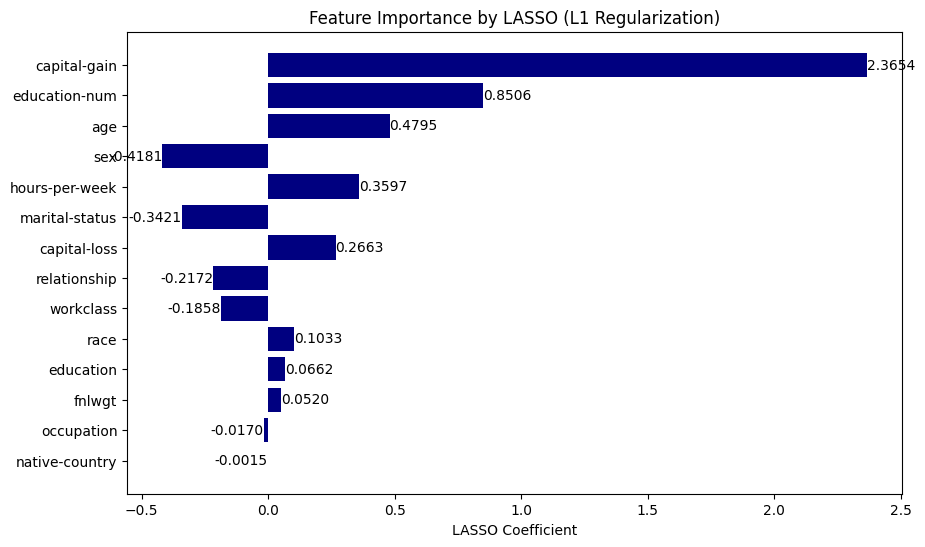

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# Prepare feature and target sets
X = df.drop('class', axis=1)
y = df['class']

# Encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

features = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

# Select only the selected features
X = X[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LASSO (L1 regularization)
start_time = time.time()
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42)
lasso.fit(X_scaled, y)
end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds")

# Extracting the feature importance
lasso_coef = np.array(lasso.coef_).flatten()
selected_features_lasso = [feature for feature, coef in zip(X.columns, lasso_coef) if coef != 0]

print("Selected features by LASSO (L1 Regularization):")
for feature, coef in zip(X.columns, lasso_coef):
    print(f"{feature}: {coef:.4f}")

# Create a DataFrame for easy sorting and visualization
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_coef
})

# Filter out zero coefficients and sort by absolute values
feature_importance = feature_importance[feature_importance['Coefficient'] != 0]
feature_importance = feature_importance.reindex(feature_importance['Coefficient'].abs().sort_values(ascending=False).index)

# Plotting the sorted features by importance
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color='navy')
plt.xlabel('LASSO Coefficient')
plt.title('Feature Importance by LASSO (L1 Regularization)')
plt.gca().invert_yaxis()  # To have the highest coefficient at the top

# Add values to the bars
for bar in bars:
    plt.text(
        bar.get_width(),  # x-coordinate of the text (end of the bar)
        bar.get_y() + bar.get_height() / 2,  # y-coordinate of the text (middle of the bar)
        f'{bar.get_width():.4f}',  # Text value with 4 decimal places
        va='center',  # Vertical alignment of text
        ha='left' if bar.get_width() > 0 else 'right'  # Horizontal alignment
    )

plt.show()


Time taken: 0.26 seconds

Feature importance by Ridge (L2 Regularization):
age: 0.4797
workclass: -0.1858
fnlwgt: 0.0522
education: 0.0665
education-num: 0.8505
marital-status: -0.3422
occupation: -0.0171
relationship: -0.2170
race: 0.1035
sex: -0.4183
capital-gain: 2.3601
capital-loss: 0.2662
hours-per-week: 0.3599
native-country: -0.0017


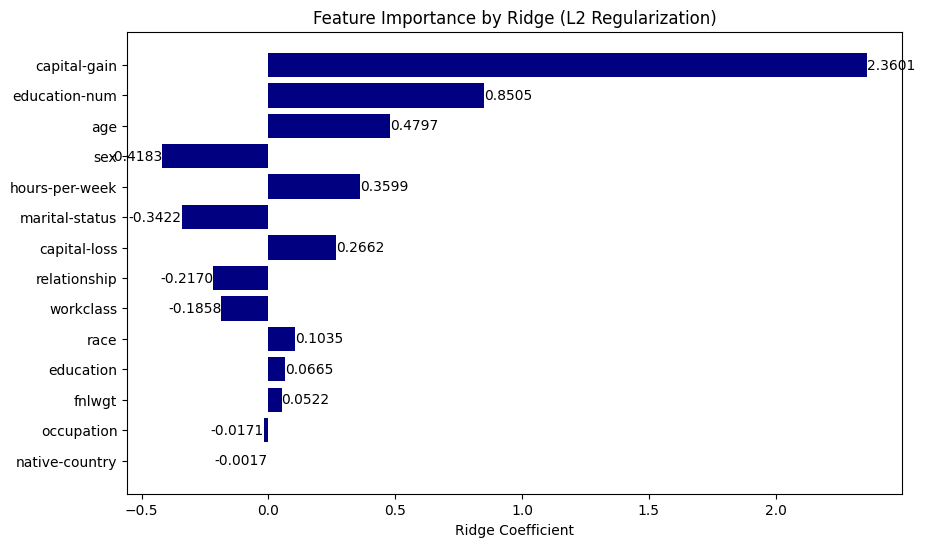

In [28]:
# Prepare feature and target sets
X = df.drop('class', axis=1)
y = df['class']

# Encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

features = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

# Select only the selected features
X = X[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ridge (L2 regularization)
start_time = time.time()
ridge = LogisticRegression(penalty='l2', solver='saga', max_iter=1000, random_state=42)
ridge.fit(X_scaled, y)
end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds")

# Extracting the feature importance
ridge_coef = np.array(ridge.coef_).flatten()

print("\nFeature importance by Ridge (L2 Regularization):")
for feature, coef in zip(X.columns, ridge_coef):
    print(f"{feature}: {coef:.4f}")

# Create a DataFrame for easy sorting and visualization
feature_importance_ridge = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_coef
})

# Sort by absolute values of the coefficients
feature_importance_ridge = feature_importance_ridge.reindex(feature_importance_ridge['Coefficient'].abs().sort_values(ascending=False).index)

# Plotting the sorted features by importance
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance_ridge['Feature'], feature_importance_ridge['Coefficient'], color='navy')
plt.xlabel('Ridge Coefficient')
plt.title('Feature Importance by Ridge (L2 Regularization)')
plt.gca().invert_yaxis()  # To have the highest coefficient at the top

# Add values to the bars
for bar in bars:
    plt.text(
        bar.get_width(),  # x-coordinate of the text (end of the bar)
        bar.get_y() + bar.get_height() / 2,  # y-coordinate of the text (middle of the bar)
        f'{bar.get_width():.4f}',  # Text value with 4 decimal places
        va='center',  # Vertical alignment of text
        ha='left' if bar.get_width() > 0 else 'right'  # Horizontal alignment
    )

plt.show()

Time taken: 0.27 seconds

Feature importance by Decision Tree:
age: 0.0479
workclass: 0.0113
fnlwgt: 0.0116
education: 0.0021
education-num: 0.2084
marital-status: 0.0012
occupation: 0.0099
relationship: 0.3871
race: 0.0018
sex: 0.0015
capital-gain: 0.2083
capital-loss: 0.0685
hours-per-week: 0.0373
native-country: 0.0030


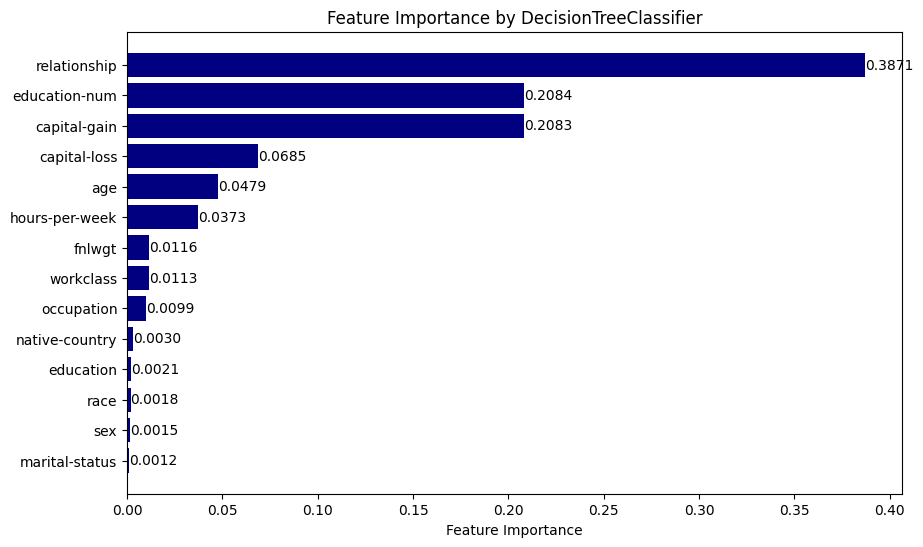

In [31]:
from sklearn.tree import DecisionTreeClassifier

# Prepare feature and target sets
X = df.drop('class', axis=1)
y = df['class']

# Encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

features = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
X = X[features]


# Train Decision Tree model
start_time = time.time()
tree_model = DecisionTreeClassifier(random_state=42, max_depth=10)
tree_model.fit(X, y)
end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds")

# Extract feature importances
feature_importances = tree_model.feature_importances_

print("\nFeature importance by Decision Tree:")
for feature, importance in zip(X.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")


# Create a DataFrame for easy sorting and visualization
feature_importance_tree_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort by feature importance
feature_importance_tree_df = feature_importance_tree_df.sort_values(by='Importance', ascending=False)

# Plotting the sorted features by importance
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance_tree_df['Feature'], feature_importance_tree_df['Importance'], color='navy')
plt.xlabel('Feature Importance')
plt.title('Feature Importance by DecisionTreeClassifier')
plt.gca().invert_yaxis()  # To have the highest importance at the top

# Add values to the bars
for bar in bars:
    plt.text(
        bar.get_width(),  # x-coordinate of the text (end of the bar)
        bar.get_y() + bar.get_height() / 2,  # y-coordinate of the text (middle of the bar)
        f'{bar.get_width():.4f}',  # Text value with 4 decimal places
        va='center',  # Vertical alignment of text
        ha='left' if bar.get_width() > 0 else 'right'  # Horizontal alignment
    )

plt.show()
